<a href="https://colab.research.google.com/github/tsilva/aiml-notebooks/blob/main/WIP-RL-CartPole_v1-A2C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RL - Solving CartPole-v1 with A2C

## Setup

First we install the packages we require:

In [24]:
!pip install gymnasium

Let's add an utility to be able to render videos in colab:

In [25]:
import cv2
import base64
import imageio
import numpy as np
from io import BytesIO
from IPython.display import HTML

def render_video(
    frames,              # List of frames to render. Each frame can be an image or a tuple (image, label)
    scale=1,             # Scale factor for the video dimensions
    fps=30,              # Frames per second for the video
    format='mp4',        # Video format
    font_scale=0.5       # Font scale for text shown in video corner
):
    def adjust_frame_size(frame, block_size=16):
        """Resize frame dimensions to be divisible by block_size."""
        height, width = frame.shape[:2]
        new_height = (height + block_size - 1) // block_size * block_size
        new_width = (width + block_size - 1) // block_size * block_size
        return cv2.resize(frame, (new_width, new_height))

    # Define text properties once
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_color = (0, 0, 0)  # Black
    line_type = 1
    margin = 10
    line_spacing = 20

    processed_frames = []
    for i, frame in enumerate(frames):
        # Determine if the frame includes a label
        if isinstance(frame, tuple) and len(frame) >= 2:
            image, label = frame
        else:
            image, label = frame, None

        # Adjust frame size
        image = adjust_frame_size(image)
        frame_with_text = image.copy()

        # If there's a label, render it
        if label:
            position = (margin, image.shape[0] - margin)
            font_color = (255, 255, 255) if len(frame_with_text.shape) == 2 else (0, 0, 0)
            cv2.putText(frame_with_text, label, position, font, font_scale, font_color, line_type)

        # Convert BGR to RGB for imageio
        _frame = frame_with_text
        if len(_frame.shape) == 2: _frame = cv2.cvtColor(frame_with_text, cv2.COLOR_GRAY2RGB)
        processed_frames.append(_frame)

    # Write video to buffer by appending frames individually
    buffer = BytesIO()
    with imageio.get_writer(buffer, format=format, fps=fps) as writer:
        for frame in processed_frames:
            writer.append_data(frame)

    # Encode video in base64
    video_data = base64.b64encode(buffer.getvalue()).decode()

    # Calculate scaled dimensions
    height, width = processed_frames[0].shape[:2]
    scaled_width, scaled_height = int(width * scale), int(height * scale)

    # Return HTML video tag
    return HTML(f'''
        <video width="{scaled_width}" height="{scaled_height}" controls autoplay loop muted>
            <source src="data:video/{format};base64,{video_data}" type="video/{format}">
            Your browser does not support the video tag.
        </video>
    ''')

# Case 1: Frames as images (no labels)
frames_images = [np.random.randint(0, 256, (128, 128), dtype=np.uint8) for _ in range(10)]
display(render_video(frames_images))

# Case 2: Frames as tuples (image, label)
frames_with_labels = [
    (np.random.randint(0, 256, (128, 128, 3), dtype=np.uint8), f"{i+1}")
    for i in range(10)
]
display(render_video(frames_with_labels))

## Train

Episode 50, Avg Reward: 17.06
Episode 100, Avg Reward: 25.62
Episode 150, Avg Reward: 38.72
Episode 200, Avg Reward: 54.22
Episode 250, Avg Reward: 74.24
Episode 300, Avg Reward: 93.84
Episode 350, Avg Reward: 127.98
Episode 400, Avg Reward: 157.44
Episode 450, Avg Reward: 185.12
Episode 500, Avg Reward: 216.58
Episode 550, Avg Reward: 237.56
Episode 600, Avg Reward: 224.36
Episode 650, Avg Reward: 210.24
Episode 700, Avg Reward: 235.38
Episode 750, Avg Reward: 239.64
Episode 800, Avg Reward: 168.36
Episode 850, Avg Reward: 294.7
Episode 900, Avg Reward: 320.42
Episode 950, Avg Reward: 355.9
Episode 1000, Avg Reward: 397.12
Episode 1050, Avg Reward: 413.8
Episode 1100, Avg Reward: 253.9
Episode 1150, Avg Reward: 400.28
Episode 1200, Avg Reward: 398.88
Episode 1250, Avg Reward: 444.32
Episode 1300, Avg Reward: 438.38
Episode 1350, Avg Reward: 482.74
Episode 1400, Avg Reward: 474.88
Episode 1450, Avg Reward: 398.0
Episode 1500, Avg Reward: 377.9
Episode 1550, Avg Reward: 401.28
Episode 1

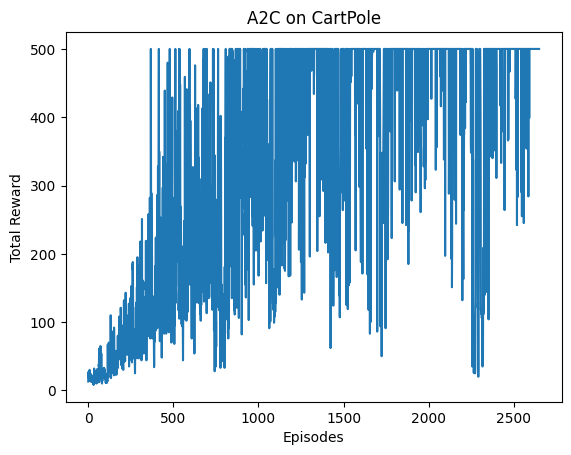

In [26]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Hyperparameters
GAMMA = 0.99  # Discount factor
LR = 0.002    # Learning rate
HIDDEN_SIZE = 128  # Hidden layer size in network
EPISODES = 10_000  # Training episodes

# Environment setup
env = gym.make("CartPole-v1")
n_state = env.observation_space.shape[0]
n_action = env.action_space.n

# Actor-Critic Network
class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(ActorCritic, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, HIDDEN_SIZE),
            nn.ReLU(),
        )
        self.actor = nn.Linear(HIDDEN_SIZE, action_dim)  # Policy head
        self.critic = nn.Linear(HIDDEN_SIZE, 1)          # Value head

    def forward(self, x):
        x = self.fc(x)
        return self.actor(x), self.critic(x)

# Initialize model and optimizer
model = ActorCritic(n_state, n_action)
optimizer = optim.Adam(model.parameters(), lr=LR)

def compute_returns(rewards, gamma):
    returns = []
    R = 0
    for r in reversed(rewards):
        R = r + gamma * R
        returns.insert(0, R)
    return torch.tensor(returns, dtype=torch.float32)

episode_rewards = []
for episode in range(EPISODES):
    state, _ = env.reset()
    log_probs = []
    values = []
    rewards = []
    total_reward = 0
    done = False

    while not done:
        state_tensor = torch.tensor(state, dtype=torch.float32)
        logits, value = model(state_tensor)
        probs = torch.softmax(logits, dim=-1)
        action = torch.multinomial(probs, 1).item()

        log_probs.append(torch.log(probs[action]))
        values.append(value)

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        rewards.append(reward)
        state = next_state
        total_reward += reward

    returns = compute_returns(rewards, GAMMA)
    values = torch.cat(values).squeeze()
    log_probs = torch.stack(log_probs)

    advantage = returns - values.detach()
    actor_loss = -log_probs * advantage
    critic_loss = (returns - values).pow(2)
    loss = actor_loss.mean() + critic_loss.mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    episode_rewards.append(total_reward)

    if (episode + 1) % 50 == 0:
        avg_reward = np.mean(episode_rewards[-50:])
        print(f"Episode {episode + 1}, Avg Reward: {avg_reward}")
        if avg_reward >= 500:
            print("Solved!")
            break

# Plot rewards
plt.plot(episode_rewards)
plt.xlabel('Episodes')
plt.ylabel('Total Reward')
plt.title('A2C on CartPole')
plt.show()

env.close()

## Evaluate

In [23]:
env = gym.make("CartPole-v1", render_mode="rgb_array")
n_state = env.observation_space.shape[0]
n_action = env.action_space.n

# Training loop
state, _ = env.reset()
done = False
frames = []
total_reward = 0
while not done:
    frame = env.render()
    frames.append(frame)
    state_tensor = torch.tensor(state, dtype=torch.float32)
    logits, value = model(state_tensor)
    probs = torch.softmax(logits, dim=-1)
    action = torch.multinomial(probs, 1).item()
    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    state = next_state
    total_reward += reward
print(f"Total Reward: {total_reward}")
render_video(frames)

Total Reward: 500.0
